## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")

# Display the first five records
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Basic info about the dataset
df.info()


### Identifying feature types

- **Numerical features:** `age`, `bmi`, `children`
- **Categorical features:** `sex`, `smoker`, `region`
- **Target variable:** `charges`


In [2]:
numerical_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']
target_variable = 'charges'

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target variable:", target_variable)


Numerical features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']
Target variable: charges


## Task 2: Data Preprocessing

In [3]:
# Check for missing values
print(df.isnull().sum())


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


No missing values are typically present in this dataset, but we check anyway as good practice.

### Encoding categorical variables
- `sex`: male/female → 0/1
- `smoker`: yes/no → 1/0
- `region`: one-hot encoded (since it has more than 2 categories)


In [4]:
df_encoded = df.copy()

# Label encode binary categorical columns
df_encoded['sex'] = df_encoded['sex'].map({'male': 0, 'female': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})

# One-hot encode 'region' (drop_first avoids the dummy variable trap)
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

df_encoded.head()


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [5]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (1070, 8)
Testing set shape: (268, 8)


## Task 3: Model Development

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Inspect learned coefficients
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coeff_df


,Coefficient
age,256.975706
sex,18.591692
bmi,337.092552
children,425.278784
smoker,23651.128856
region_northwest,-370.677326
region_southeast,-657.864297
region_southwest,-809.799354


## Task 4: Model Evaluation

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error (MAE): 4181.19
Mean Squared Error (MSE): 33596915.85
R² Score: 0.7836


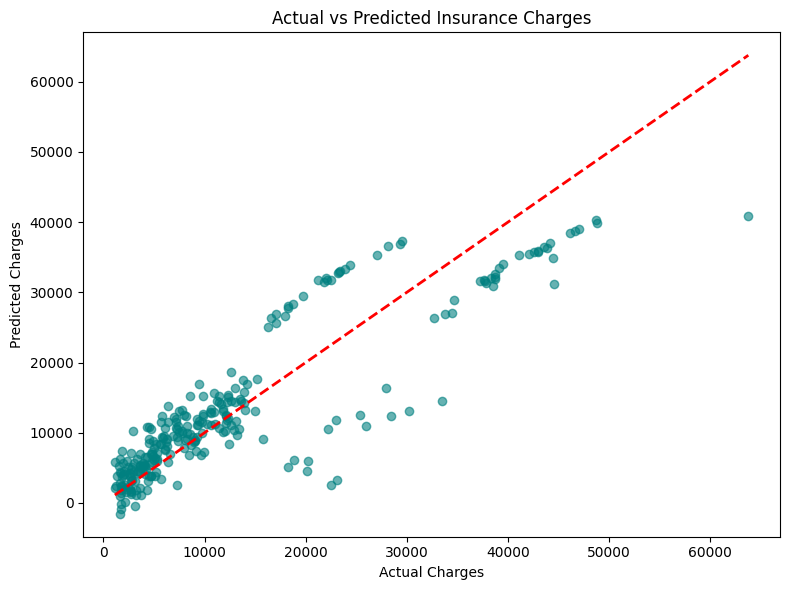

In [10]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()


### Observations

1. The model achieves an R² score of 0.7836, meaning it explains about 78% of the variance in insurance charges — a reasonably strong fit for a linear model on this data.
2. The Mean Absolute Error of 4181.19 means predictions are off by about $4,181 on average, which is moderate relative to charges that range from a few hundred to over $60,000.
3. The Actual vs Predicted plot shows the model tracks well for lower charges (under ~$15,000) but consistently underpredicts for higher actual charges, especially the highest values — this is the model failing to capture the sharp cost jump associated with smoking combined with other risk factors, which a straight-line relationship can't fully represent.



## Task 5: Conclusion

This project used Multiple Linear Regression to predict medical insurance charges from a customer's age, sex, BMI, number of children, smoking status, and region. After encoding categorical variables and splitting the data 80/20, the model achieved a Mean Absolute Error of 4181.19, a Mean Squared Error of 33,596,915.85, and an R² score of 0.7836 on the test set, meaning it explains roughly 78% of the variation in charges. Smoking status emerged as the strongest predictor of charges, followed by age and BMI, aligning with domain expectations that smokers and older, higher-BMI individuals face higher health risks and costs. Sex and region contributed comparatively little to the prediction.

A key limitation of Linear Regression here is its assumption of a linear relationship between features and charges. In reality, the interaction between smoking and BMI produces a sharp, non-linear jump in cost for smokers, which the model consistently underpredicts, as seen in the higher-charge region of the actual-vs-predicted plot. Non-linear models such as polynomial regression, random forests, or gradient boosting would likely capture this interaction more accurately and reduce error for high-cost individuals.
